# NYCCAS Analytics — Control Charts & Forecasting

**Purpose:** Analyze NYCCAS seasonal and yearly air quality data (PM2.5, NO2, O3) and produce publication-ready control charts, plus short-term forecasts using multiple predictive models.

**Data sources:** CSV files in the `data_csv/` folder, including `NYCCAS-PM25.csv`, `NYCCAS-NO2.csv`, `NYCCAS-O3.csv`, and `NYCCAS-Seasonal-Borough.csv`.

**Primary outputs:**
- Visual control charts for seasonal air quality metrics.
- Short-term forecast summaries for selected pollutants.

**Dependencies:**
- Python 3.8+
- `pandas`, `numpy`, `matplotlib`, `scikit-learn`, `statsmodels`
- See `requirements.txt` or `environment.yml` for exact versions.

**How to run:**
1. Activate the project virtual environment (if present):
```bash
source .venv/bin/activate
```
2. Run the notebook cells in order. Ensure the required `data_csv/` files exist and adjust forecast years or model settings as needed.

**Notes & reproducibility:**
- Seasonal files are standardized using a helper `load_and_melt()` function.
- Control charts use the grand mean ± 3×sample standard deviation for UCL/LCL.
- Forecasting comparisons include Linear, Polynomial, Decision Tree, and Exponential Smoothing models.

**Author / Maintainer:** Mayank Anand — mayank.anand3007@gmail.com

In [1]:
# Consolidated imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ML / forecasting imports (kept at top for reproducibility)
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [2]:
# Common constants
SEASON_ORDER = ["winter", "spring", "summer", "fall"]
# For black & white figures: assign marker, linestyle, and marker size per season
SEASON_MARKERS = {"winter": "s", "spring": "^", "summer": "o", "fall": "D"}
SEASON_STYLES  = {"winter": "-", "spring": "--", "summer": ":", "fall": "-."}
SEASON_SIZES   = {"winter": 6, "spring": 5, "summer": 5, "fall": 6}

# Helper: load and melt seasonal data consistently
def load_and_melt(path, season_order=SEASON_ORDER):
    ny = pd.read_csv(path)
    ny.columns = [c.strip().lower() for c in ny.columns]
    required = ["year"] + list(season_order)
    if not all(c in ny.columns for c in required):
        raise ValueError(f"Expected columns {required}, got {list(ny.columns)}")
    m = (
        ny[["year"] + list(season_order)]
        .melt(id_vars=["year"], value_vars=list(season_order),
              var_name="season", value_name="value")
        .dropna(subset=["value"])
    )
    m["season_ord"] = m["season"].map({s: i for i, s in enumerate(season_order)})
    m = m.sort_values(["year", "season_ord"]).reset_index(drop=True)
    m["seq"] = np.arange(len(m))
    return ny, m

# PM2.5

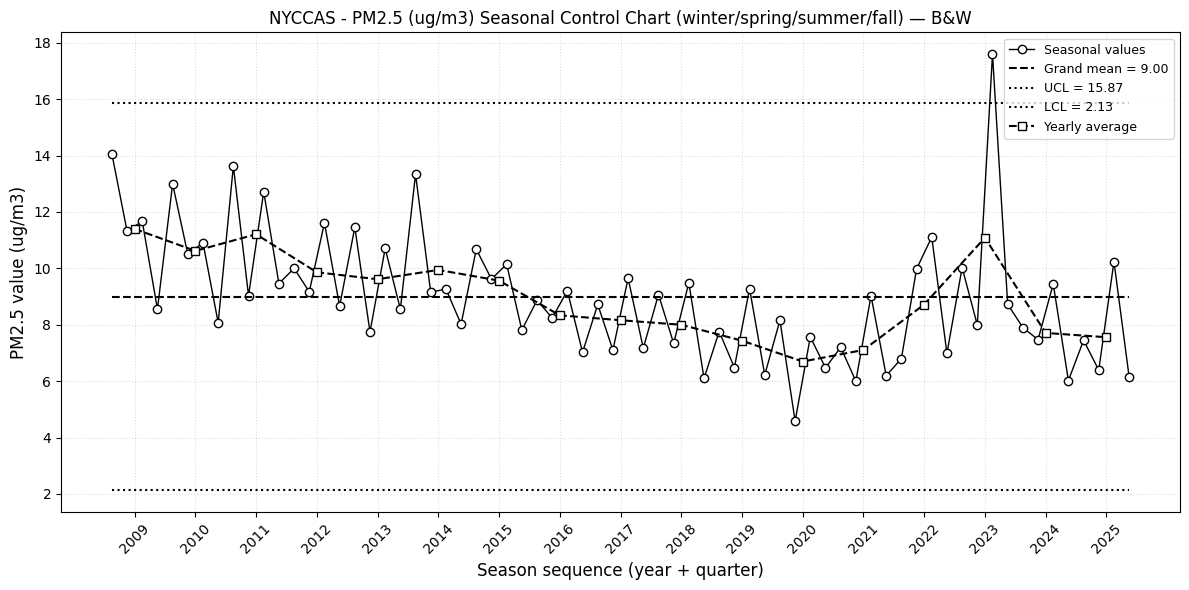

overall mean: 9.0010, std: 2.2889, UCL: 15.8679, LCL: 2.1342
    year    value
0   2009  11.4000
1   2010  10.6200
2   2011  11.2100
3   2012   9.8600
4   2013   9.6150
5   2014   9.9450
6   2015   9.5650
7   2016   8.3350
8   2017   8.1600
9   2018   8.0000
10  2019   7.4350
11  2020   6.6950
12  2021   7.1050
13  2022   8.7175
14  2023  11.0875
15  2024   7.7100
16  2025   7.5575


In [11]:
# Reuse helper: load and melt seasonal data
nyccas, m = load_and_melt("data_csv/NYCCAS-PM25.csv")

# Yearly means and overall stats
year_means = m.groupby("year", as_index=False)["value"].mean()
overall_mean = m["value"].mean()
overall_std  = m["value"].std(ddof=1)
ucl = overall_mean + 3 * overall_std
lcl = overall_mean - 3 * overall_std

# Plot control chart (black & white)
fig, ax = plt.subplots(figsize=(12, 6))
# Seasonal values as thin black line with open markers
ax.plot(m["seq"], m["value"], "-o", color="black", markerfacecolor="white", label="Seasonal values", linewidth=1)
# Grand mean and control limits in black (dashed/dotted)
ax.plot(m["seq"], [overall_mean] * len(m), "--", color="black", label=f"Grand mean = {overall_mean:.2f}")
ax.plot(m["seq"], [ucl] * len(m), ":", color="black", label=f"UCL = {ucl:.2f}")
ax.plot(m["seq"], [lcl] * len(m), ":", color="black", label=f"LCL = {lcl:.2f}")

# Plot yearly means as black squares connected with dashed line
year_pos = m.groupby("year")["seq"].mean().values
ax.plot(year_pos, year_means["value"], "s--", color="black", markerfacecolor="white", label="Yearly average")

# Annotation
ax.set_title("NYCCAS - PM2.5 (ug/m3) Seasonal Control Chart (winter/spring/summer/fall) — B&W")
ax.set_xlabel("Season sequence (year + quarter)", fontsize=12)
ax.set_ylabel("PM2.5 value (ug/m3)", fontsize=12)
ax.set_xticks(year_pos)
ax.set_xticklabels(year_means["year"].astype(int).tolist(), rotation=45)
ax.grid(True, linestyle=":", alpha=0.4)
ax.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()

print(f"overall mean: {overall_mean:.4f}, std: {overall_std:.4f}, UCL: {ucl:.4f}, LCL: {lcl:.4f}")
print(year_means)

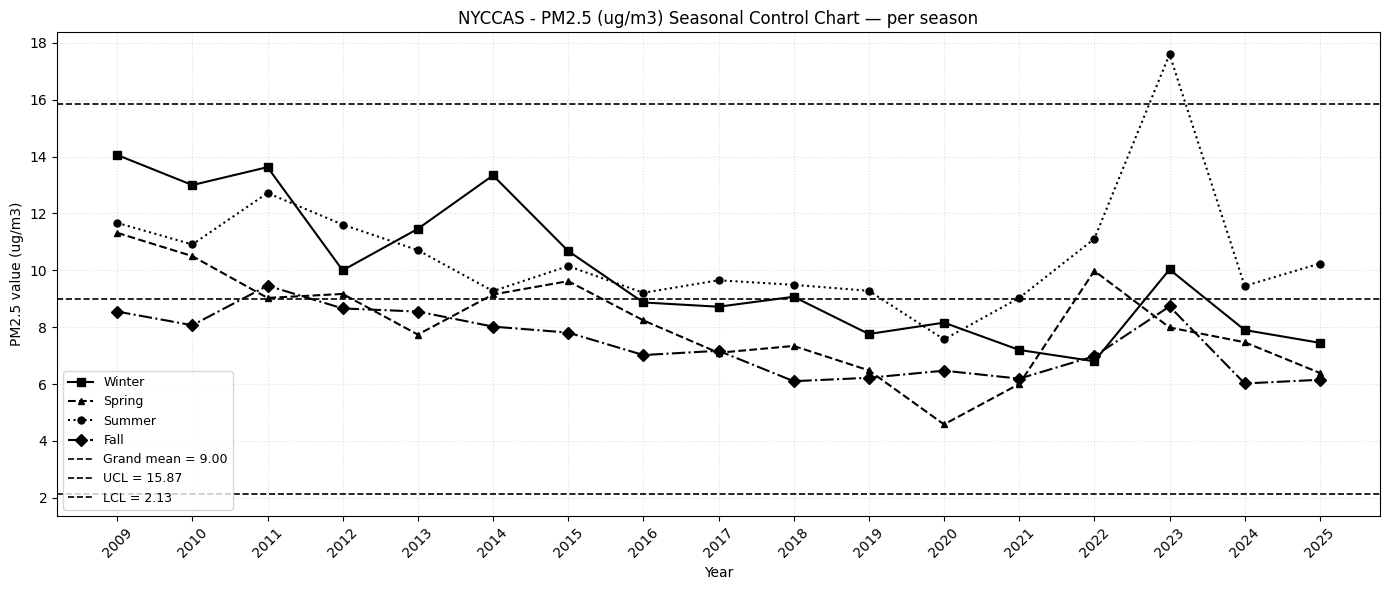

overall mean: 9.0010, std: 2.2889,  UCL: 15.8679, LCL: 2.1342
    year    value
0   2009  11.4000
1   2010  10.6200
2   2011  11.2100
3   2012   9.8600
4   2013   9.6150
5   2014   9.9450
6   2015   9.5650
7   2016   8.3350
8   2017   8.1600
9   2018   8.0000
10  2019   7.4350
11  2020   6.6950
12  2021   7.1050
13  2022   8.7175
14  2023  11.0875
15  2024   7.7100
16  2025   7.5575


In [4]:
# Reuse helper to load and melt
nyccas, m = load_and_melt("data_csv/NYCCAS-PM25.csv")

# Yearly means and overall stats
year_means  = m.groupby("year", as_index=False)["value"].mean()
overall_mean = m["value"].mean()
overall_std  = m["value"].std(ddof=1)
ucl = overall_mean + 3 * overall_std
lcl = overall_mean - 3 * overall_std

# Plot control chart — one line per season (black & white)
fig, ax = plt.subplots(figsize=(14, 6))

for season in SEASON_ORDER:
    s = m[m["season"] == season].sort_values("year")
    ax.plot(s["year"], s["value"],
            linestyle=SEASON_STYLES[season],
            color="black",
            marker=SEASON_MARKERS[season],
            markersize=SEASON_SIZES[season],
            label=season.capitalize(), linewidth=1.5)

# Control-chart reference lines
ax.axhline(overall_mean, linestyle="--", color="black",  linewidth=1.2,
           label=f"Grand mean = {overall_mean:.2f}")
ax.axhline(ucl,          linestyle="--", color="black",    linewidth=1.2,
           label=f"UCL = {ucl:.2f}")
ax.axhline(lcl,          linestyle="--", color="black",    linewidth=1.2,
           label=f"LCL = {lcl:.2f}")

ax.set_xticks(year_means["year"].astype(int).tolist())
ax.set_xticklabels(year_means["year"].astype(int).tolist(), rotation=45)

ax.set_title("NYCCAS - PM2.5 (ug/m3) Seasonal Control Chart — per season")
ax.set_xlabel("Year")
ax.set_ylabel("PM2.5 value (ug/m3)")
ax.grid(True, linestyle=":", alpha=0.4)
ax.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()

print(f"overall mean: {overall_mean:.4f}, std: {overall_std:.4f}, ",
      f"UCL: {ucl:.4f}, LCL: {lcl:.4f}")
print(year_means)

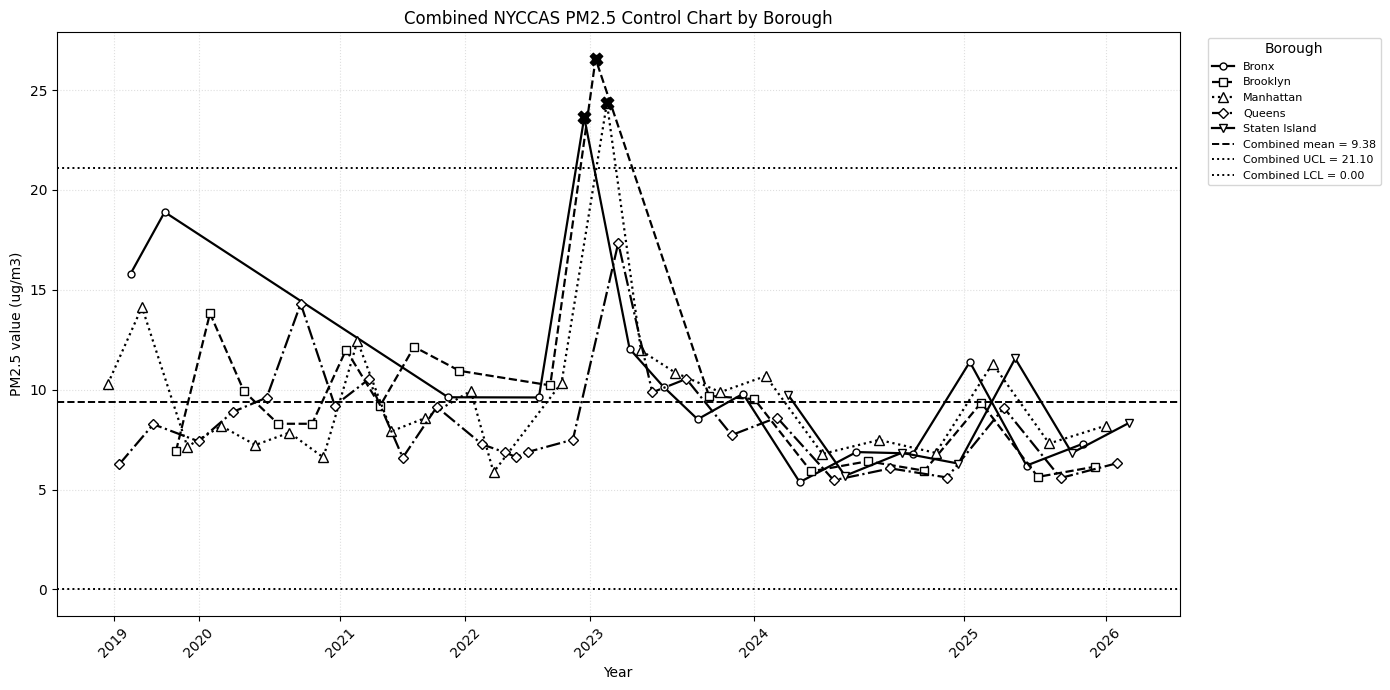

combined mean: 9.3814, std: 3.9056, UCL: 21.0982, LCL: 0.0000
   Year    Borough  Season      Value
0  2019  Manhattan    Fall  10.299097
1  2019     Queens    Fall   6.263357
2  2020      Bronx  Winter  15.805796
3  2020  Manhattan  Winter  14.133569
4  2020     Queens  Winter   8.266367


In [5]:
# Load borough seasonal data
nyccas_borough = pd.read_csv("data_csv/NYCCAS-Seasonal-Borough.csv")

required_borough = ["Borough", "Year", "Value", "Season"]
if not all(c in nyccas_borough.columns for c in required_borough):
    raise ValueError(f"Expected columns {required_borough}, got {list(nyccas_borough.columns)}")

m_borough = nyccas_borough.copy()
m_borough["Borough"] = m_borough["Borough"].str.strip().str.title()
m_borough["Season"] = m_borough["Season"].str.strip().str.title()
season_order = [s.title() for s in SEASON_ORDER]
m_borough["season_ord"] = m_borough["Season"].map({s: i for i, s in enumerate(season_order)})
m_borough = m_borough.sort_values(["Year", "season_ord", "Borough"]).reset_index(drop=True)
m_borough["seq"] = np.arange(len(m_borough))

# Combined control limits across all borough-season observations
combined_mean = m_borough["Value"].mean()
combined_std = m_borough["Value"].std(ddof=1)
combined_ucl = combined_mean + 3 * combined_std
combined_lcl = max(combined_mean - 3 * combined_std, 0)

boroughs = sorted(m_borough["Borough"].dropna().unique())
# black & white styling: cycle markers and linestyles per borough
marker_cycle = ["o", "s", "^", "D", "v", "<", ">", "p"]
linestyle_cycle = ["-", "--", ":", "-.", "-", "--", ":", "-."]

fig, ax = plt.subplots(figsize=(14, 7))

for i, borough in enumerate(boroughs):
    b_data = m_borough[m_borough["Borough"] == borough].sort_values(["Year", "season_ord"])
    marker = marker_cycle[i % len(marker_cycle)]
    ls = linestyle_cycle[i % len(linestyle_cycle)]
    ax.plot(
        b_data["seq"],
        b_data["Value"],
        linestyle=ls,
        color="black",
        linewidth=1.6,
        marker=marker,
        markersize=5 + (i % 3),
        markerfacecolor="white",
        markeredgecolor="black",
        label=borough
    )

    out_of_control = (b_data["Value"] > combined_ucl) | (b_data["Value"] < combined_lcl)
    if out_of_control.any():
        ax.scatter(
            b_data.loc[out_of_control, "seq"],
            b_data.loc[out_of_control, "Value"],
            color="black",
            edgecolor="black",
            s=80,
            zorder=5,
            marker="X"
        )

ax.axhline(combined_mean, linestyle="--", color="black", linewidth=1.4, label=f"Combined mean = {combined_mean:.2f}")
ax.axhline(combined_ucl, linestyle=":", color="black", linewidth=1.4, label=f"Combined UCL = {combined_ucl:.2f}")
ax.axhline(combined_lcl, linestyle=":", color="black", linewidth=1.4, label=f"Combined LCL = {combined_lcl:.2f}")

year_pos = m_borough.groupby("Year")["seq"].mean().values
year_labels = m_borough.groupby("Year").size().index.astype(int).tolist()
ax.set_xticks(year_pos)
ax.set_xticklabels(year_labels, rotation=45)

ax.set_title("Combined NYCCAS PM2.5 Control Chart by Borough")
ax.set_xlabel("Year")
ax.set_ylabel("PM2.5 value (ug/m3)")
ax.grid(True, linestyle=":", alpha=0.4)
ax.legend(title="Borough", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

print(f"combined mean: {combined_mean:.4f}, std: {combined_std:.4f}, UCL: {combined_ucl:.4f}, LCL: {combined_lcl:.4f}")
print(m_borough[["Year", "Borough", "Season", "Value"]].head())

# NO2

In [6]:
# Uses consolidated imports defined in the notebook first cell

# -----------------------------
# 1. Load Data
# -----------------------------
df = pd.read_csv("data_csv/NYCCAS-NO2.csv")
df = df.astype(float)

# -----------------------------
# 2. Features
# -----------------------------
X = df[["year"]]   # independent variable
forecast_years = pd.DataFrame({"year": [2024, 2025]})

# Polynomial transformation
poly = PolynomialFeatures(degree=2)   # ✅ degree 2 is best for small data
X_poly = poly.fit_transform(X)
future_poly = poly.transform(forecast_years)

# -----------------------------
# 3. Storage
# -----------------------------
forecast_df = pd.DataFrame({"year": [2024, 2025]})
results = []

# -----------------------------
# 4. Model Loop
# -----------------------------
for season in ["winter", "spring", "summer", "fall"]:
    
    y = df[season]
    
    # Train-test split (last 3 years as test)
    X_train, X_test = X[:-3], X[-3:]
    y_train, y_test = y[:-3], y[-3:]
    
    # ------------------ Linear Regression ------------------
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    pred_lr = lr.predict(X_test)
    rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
    
    forecast_lr = lr.predict(forecast_years)
    
    # ------------------ Polynomial Regression ------------------
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    pr = LinearRegression()
    pr.fit(X_train_poly, y_train)
    pred_pr = pr.predict(X_test_poly)
    rmse_pr = np.sqrt(mean_squared_error(y_test, pred_pr))
    
    forecast_pr = pr.predict(future_poly)
    
    # ------------------ Decision Tree ------------------
    dt = DecisionTreeRegressor(max_depth=3)
    dt.fit(X_train, y_train)
    pred_dt = dt.predict(X_test)
    rmse_dt = np.sqrt(mean_squared_error(y_test, pred_dt))
    
    forecast_dt = dt.predict(forecast_years)
    
    # ------------------ Exponential Smoothing
    es_model = ExponentialSmoothing(y_train, trend="add")
    es_fit = es_model.fit()
    
    pred_es = es_fit.forecast(steps=3)
    rmse_es = np.sqrt(mean_squared_error(y_test, pred_es))
    
    forecast_es = es_fit.forecast(steps=2)
    
    # ------------------ Store Forecasts ------------------
    forecast_df[f"{season}_lr"] = forecast_lr
    forecast_df[f"{season}_poly"] = forecast_pr
    forecast_df[f"{season}_dt"] = forecast_dt
    forecast_df[f"{season}_es"] = forecast_es.values
    
    # ------------------ Store RMSE ------------------
    results.append({
        "season": season,
        "Linear RMSE": rmse_lr,
        "Polynomial RMSE": rmse_pr,
        "DecisionTree RMSE": rmse_dt,
        "ExpSmooth RMSE": rmse_es
    })

# -----------------------------
# 5. Results
# -----------------------------
results_df = pd.DataFrame(results)

print("\nModel Comparison (RMSE):")
print(results_df)

print("\nForecasted Values:")
print(forecast_df)


Model Comparison (RMSE):
   season  Linear RMSE  Polynomial RMSE  DecisionTree RMSE  ExpSmooth RMSE
0  winter     1.223241         1.217873           1.221270        1.223241
1  spring     1.732656         1.733154           3.779330        1.732656
2  summer     2.218875         0.702229           0.742720        1.943045
3    fall     2.945380         1.857683           1.102905        2.945380

Forecasted Values:
   year  winter_lr  winter_poly  winter_dt  winter_es  spring_lr  spring_poly  \
0  2024  22.391033    22.546418      23.13  22.930659  13.478176    13.316253   
1  2025  21.851407    22.056736      23.13  22.391033  12.542835    12.328865   

   spring_dt  spring_es  summer_lr  summer_poly  summer_dt  summer_es  \
0      16.67  14.413516  11.431077    13.110692      13.93  12.482569   
1      16.67  13.478176  10.667758    12.887250      13.93  11.709300   

     fall_lr  fall_poly  fall_dt    fall_es  
0  17.144989  18.314604    19.32  17.671209  
1  16.618769  18.164332

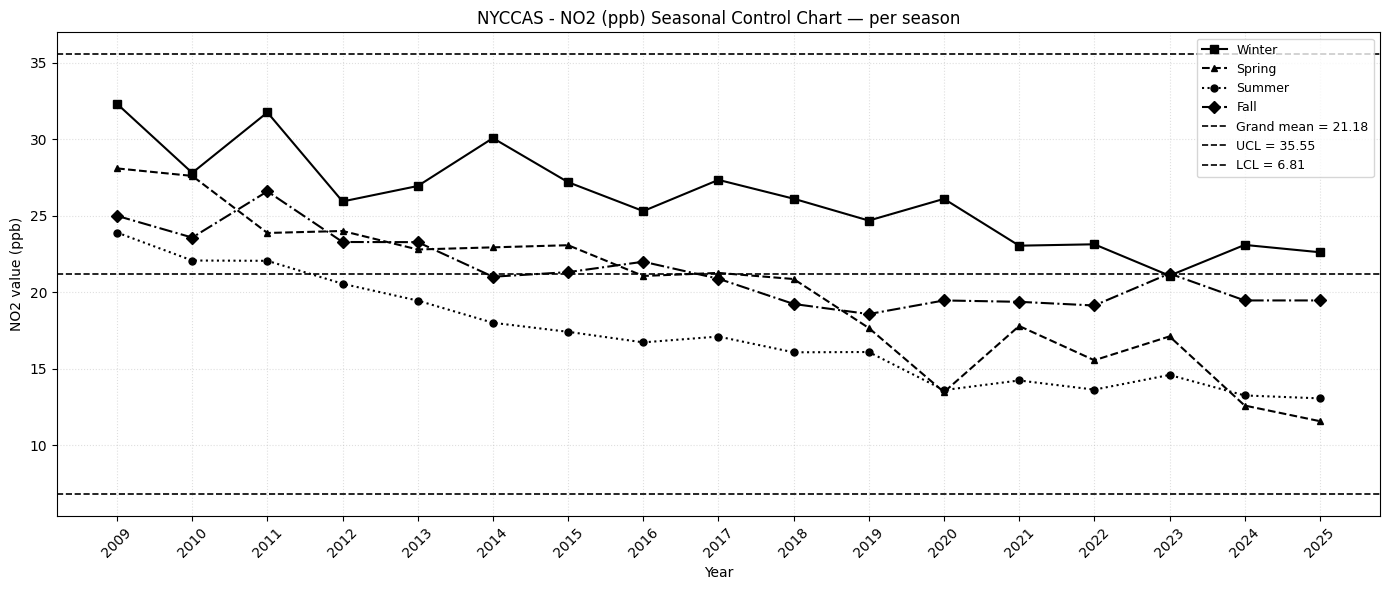

overall mean: 21.1809, std: 4.7888,  UCL: 35.5472, LCL: 6.8146
    year    value
0   2009  27.3225
1   2010  25.2600
2   2011  26.0650
3   2012  23.4400
4   2013  23.1125
5   2014  23.0025
6   2015  22.2450
7   2016  21.2675
8   2017  21.6450
9   2018  20.5675
10  2019  19.2500
11  2020  18.1575
12  2021  18.6075
13  2022  17.8600
14  2023  18.5000
15  2024  17.0975
16  2025  16.6750


In [7]:
# Load and normalize column names
nyccas = pd.read_csv("data_csv/NYCCAS-NO2.csv")
nyccas.columns = [c.strip().lower() for c in nyccas.columns]
required = ["year", "winter", "spring", "summer", "fall"]
if not all(c in nyccas.columns for c in required):
    raise ValueError(f"Expected columns {required}, got {list(nyccas.columns)}")

# Melt seasonal values into one sequence by year+season
season_order = ["winter", "spring", "summer", "fall"]
# Black & white markers/styles
season_markers = {"winter": "s", "spring": "^", "summer": "o", "fall": "D"}
season_styles  = {"winter": "-", "spring": "--", "summer": ":", "fall": "-."}
season_sizes   = {"winter": 6, "spring": 5, "summer": 5, "fall": 6}

m = (
    nyccas[["year"] + season_order]
    .melt(id_vars=["year"], value_vars=season_order,
          var_name="season", value_name="value")
    .dropna(subset=["value"])
)
m["season_ord"] = m["season"].map({s: i for i, s in enumerate(season_order)})
m = m.sort_values(["year", "season_ord"]).reset_index(drop=True)
m["seq"] = np.arange(len(m))

# Yearly means and overall stats
year_means  = m.groupby("year", as_index=False)["value"].mean()
overall_mean = m["value"].mean()
overall_std  = m["value"].std(ddof=1)
ucl = overall_mean + 3 * overall_std
lcl = overall_mean - 3 * overall_std

# Plot control chart — one line per season (black & white)
fig, ax = plt.subplots(figsize=(14, 6))

for season in season_order:
    s = m[m["season"] == season].sort_values("year")
    ax.plot(s["year"], s["value"],
            linestyle=season_styles[season],
            color="black",
            marker=season_markers[season],
            markersize=season_sizes[season],
            label=season.capitalize(), linewidth=1.5)

# Control-chart reference lines
ax.axhline(overall_mean, linestyle="--", color="black",  linewidth=1.2,
           label=f"Grand mean = {overall_mean:.2f}")
ax.axhline(ucl,          linestyle="--", color="black",    linewidth=1.2,
           label=f"UCL = {ucl:.2f}")
ax.axhline(lcl,          linestyle="--", color="black",    linewidth=1.2,
           label=f"LCL = {lcl:.2f}")

ax.set_xticks(year_means["year"].astype(int).tolist())
ax.set_xticklabels(year_means["year"].astype(int).tolist(), rotation=45)

ax.set_title("NYCCAS - NO2 (ppb) Seasonal Control Chart — per season")
ax.set_xlabel("Year")
ax.set_ylabel("NO2 value (ppb)")
ax.grid(True, linestyle=":", alpha=0.4)
ax.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()

print(f"overall mean: {overall_mean:.4f}, std: {overall_std:.4f}, ",
      f"UCL: {ucl:.4f}, LCL: {lcl:.4f}")
print(year_means)

# 03

In [8]:
# Uses consolidated imports defined in the notebook first cell

# -----------------------------
# 1. Load Data
# -----------------------------
df = pd.read_csv("data_csv/NYCCAS-O3.csv")
df = df.astype(float)

# -----------------------------
# 2. Features
# -----------------------------
X = df[["year"]]   # independent variable
forecast_years = pd.DataFrame({"year": [2024, 2025]})

# Polynomial transformation
poly = PolynomialFeatures(degree=2)   # ✅ degree 2 is best for small data
X_poly = poly.fit_transform(X)
future_poly = poly.transform(forecast_years)

# -----------------------------
# 3. Storage
# -----------------------------
forecast_df = pd.DataFrame({"year": [2024, 2025]})
results = []

# -----------------------------
# 4. Model Loop
# -----------------------------
for season in ["summer"]:
    
    y = df[season]
    
    # Train-test split (last 3 years as test)
    X_train, X_test = X[:-3], X[-3:]
    y_train, y_test = y[:-3], y[-3:]
    
    # ------------------ Linear Regression ------------------
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    pred_lr = lr.predict(X_test)
    rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
    
    forecast_lr = lr.predict(forecast_years)
    
    # ------------------ Polynomial Regression ------------------
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    pr = LinearRegression()
    pr.fit(X_train_poly, y_train)
    pred_pr = pr.predict(X_test_poly)
    rmse_pr = np.sqrt(mean_squared_error(y_test, pred_pr))
    
    forecast_pr = pr.predict(future_poly)
    
    # ------------------ Decision Tree ------------------
    dt = DecisionTreeRegressor(max_depth=3)
    dt.fit(X_train, y_train)
    pred_dt = dt.predict(X_test)
    rmse_dt = np.sqrt(mean_squared_error(y_test, pred_dt))
    
    forecast_dt = dt.predict(forecast_years)
    
    # ------------------ Exponential Smoothing ------------------
    es_model = ExponentialSmoothing(y_train, trend="add")
    es_fit = es_model.fit()
    
    pred_es = es_fit.forecast(steps=3)
    rmse_es = np.sqrt(mean_squared_error(y_test, pred_es))
    
    forecast_es = es_fit.forecast(steps=2)
    
    # ------------------ Store Forecasts ------------------
    forecast_df[f"{season}_lr"] = forecast_lr
    forecast_df[f"{season}_poly"] = forecast_pr
    forecast_df[f"{season}_dt"] = forecast_dt
    forecast_df[f"{season}_es"] = forecast_es.values
    
    # ------------------ Store RMSE ------------------
    results.append({
        "season": season,
        "Linear RMSE": rmse_lr,
        "Polynomial RMSE": rmse_pr,
        "DecisionTree RMSE": rmse_dt,
        "ExpSmooth RMSE": rmse_es
    })

# -----------------------------
# 5. Results
# -----------------------------
results_df = pd.DataFrame(results)

print("\nModel Comparison (RMSE):")
print(results_df)

print("\nForecasted Values:")
print(forecast_df)


Model Comparison (RMSE):
   season  Linear RMSE  Polynomial RMSE  DecisionTree RMSE  ExpSmooth RMSE
0  summer      1.45622         2.200031           1.192686        1.456218

Forecasted Values:
   year  summer_lr  summer_poly  summer_dt  summer_es
0  2024  31.336242    30.104319      32.21  31.194841
1  2025  31.477648    29.849750      32.21  31.336247


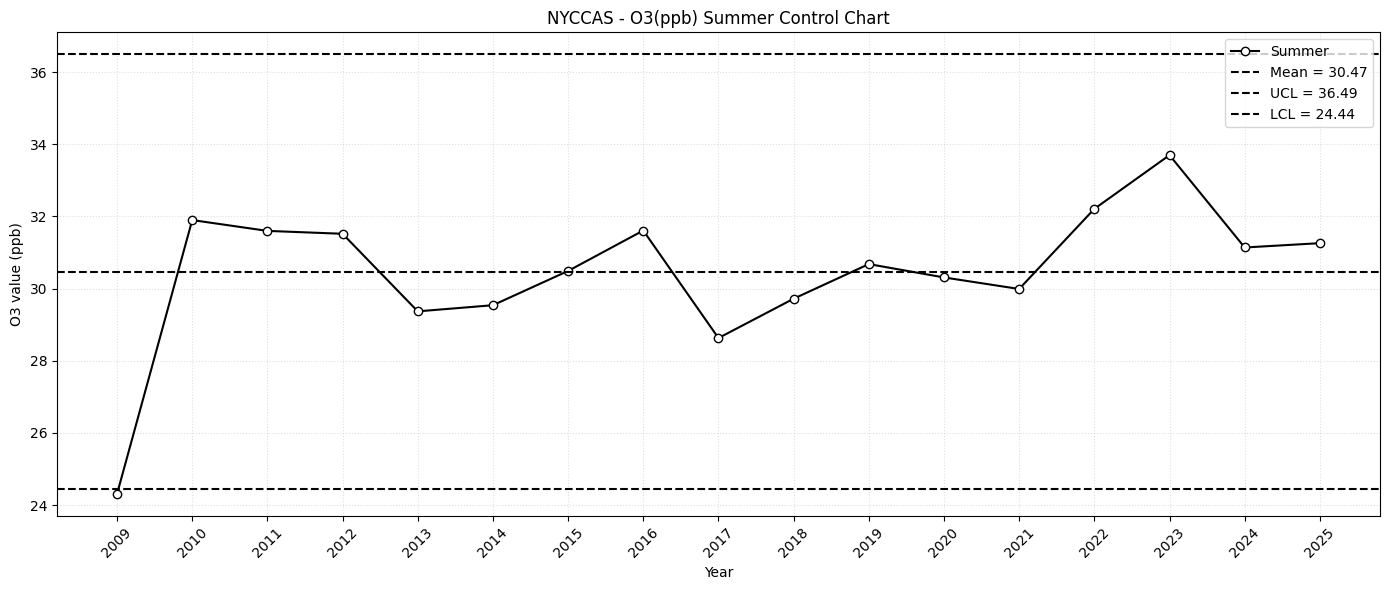

overall mean: 30.4694, std: 2.0082,  UCL: 36.4940, LCL: 24.4448
    year  value
0   2009  24.31
1   2010  31.90
2   2011  31.60
3   2012  31.52
4   2013  29.37
5   2014  29.54
6   2015  30.49
7   2016  31.61
8   2017  28.63
9   2018  29.72
10  2019  30.68
11  2020  30.31
12  2021  29.99
13  2022  32.21
14  2023  33.70
15  2024  31.14
16  2025  31.26


In [9]:
# Reuse helper to load and melt (only summer present)
nyccas, m = load_and_melt("data_csv/NYCCAS-O3.csv", season_order=["summer"])
season_colors = {"summer": "tab:orange"}
season_markers = {"summer": "o"}
season_styles  = {"summer": "-"}

m["season_ord"] = 0
m = m.sort_values(["year"]).reset_index(drop=True)
m["seq"] = np.arange(len(m))

# ---- Stats ----
year_means  = m.groupby("year", as_index=False)["value"].mean()
overall_mean = m["value"].mean()
overall_std  = m["value"].std(ddof=1)
ucl = overall_mean + 3 * overall_std
lcl = overall_mean - 3 * overall_std

# ---- Plot ----
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(m["year"], m["value"], linestyle=season_styles["summer"], color="black", marker=season_markers["summer"], markersize=6,
        label="Summer", linewidth=1.5, markerfacecolor="white", markeredgecolor="black")

# Control lines
ax.axhline(overall_mean, linestyle="--", color="black",
           label=f"Mean = {overall_mean:.2f}")
ax.axhline(ucl, linestyle="--", color="black",
           label=f"UCL = {ucl:.2f}")
ax.axhline(lcl, linestyle="--", color="black",
           label=f"LCL = {lcl:.2f}")

ax.set_xticks(m["year"])
ax.set_xticklabels(m["year"], rotation=45)

ax.set_title("NYCCAS - O3(ppb) Summer Control Chart")
ax.set_xlabel("Year")
ax.set_ylabel("O3 value (ppb)")
ax.grid(True, linestyle=":", alpha=0.4)
ax.legend()

plt.tight_layout()
plt.show()

# ---- Output stats ----
print(f"overall mean: {overall_mean:.4f}, std: {overall_std:.4f}, ",
      f"UCL: {ucl:.4f}, LCL: {lcl:.4f}")
print(year_means)